In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_Larsson

In [2]:
dim = 1
M = 1e-2
p = 4
v0 = 1.7e-14 * M ** 4 # 多田さんのノートの式

def infPotFunc(phi):
    x = phi / M
    return v0 * (1 - x ** p) ** 2

def infPotDerivFunc(phi):
    x = phi / M
    return -2 * p * v0 / M * (1 - x ** p) * x ** (p - 1)

def infPotDeriv2Func(phi):
    x = phi / M
    return 2 * p * v0 / M / M * ((2 * p - 1) * x ** p - p + 1) * x ** (p - 2)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

nGrid = 256
upperBound = (M * M / 2 / p / (p - 1)) ** (1 / (p - 2)) * M
lowerBound = -upperBound

In [3]:
fpFinDiff = InfAdjFPFiniteDiff_Larsson(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    nGrid,
    upperBound,
    lowerBound
)

In [4]:
fpFinDiff

array([[ 1.53883008e+13, -2.84416921e-11,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.84416921e-11,  1.46781969e+13, -2.84416921e-11, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -2.84416921e-11,  1.39956126e+13, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.39956126e+13, -2.84416921e-11,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.84416921e-11,  1.46781969e+13, -2.84416921e-11],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -2.84416921e-11,  1.53883008e+13]])

In [5]:
eigVals, eigVecs = np.linalg.eig(fpFinDiff)
eigVecsSort = eigVecs.T[np.argsort(eigVals)]
eigValsSort = np.sort(eigVals)

In [6]:
import matplotlib.pyplot as plt

In [7]:
nMode = np.arange(1, nGrid + 1)
eigValsFlat = [np.pi ** 2 * v0 / (24 * np.pi ** 2) / (upperBound - lowerBound) ** 2 * n ** 2 for n in nMode]

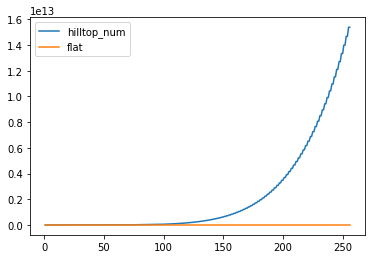

In [8]:
ax = plt.gca()
plt.plot(nMode, eigValsSort, label = "hilltop_num")
plt.plot(nMode, eigValsFlat, label = "flat")
plt.legend()
plt.show()

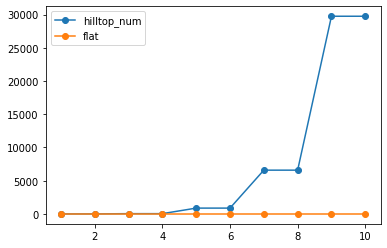

In [9]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort[:10], marker='o', label = "hilltop_num")
plt.plot(np.arange(1, 11), eigValsFlat[:10], marker='o', label = "flat")
plt.legend()
plt.show()

In [10]:
print(eigValsSort[:10])
print(eigValsFlat[:10])

[5.59768325e-02 5.59768326e-02 4.08016604e+01 4.08016604e+01
 8.74519914e+02 8.74519914e+02 6.58472812e+03 6.58472812e+03
 2.97443614e+04 2.97443614e+04]
[4.25e-15, 1.7e-14, 3.825e-14, 6.8e-14, 1.0625e-13, 1.53e-13, 2.0825e-13, 2.72e-13, 3.4425e-13, 4.25e-13]


考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [11]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

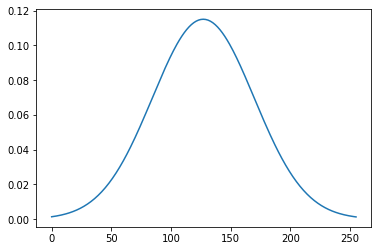

In [12]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

In [13]:
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort]

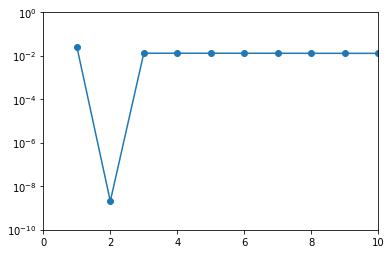

In [14]:
# 各固有ベクトルの寄与度
ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
plt.yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

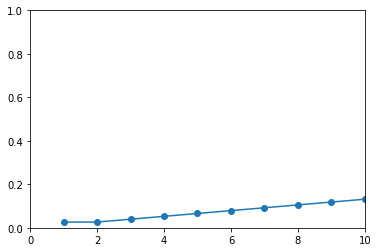

In [15]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()

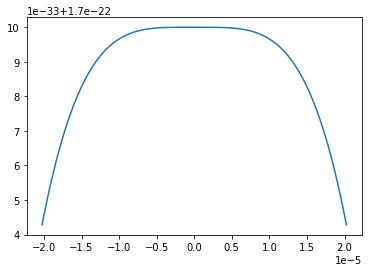

In [16]:
# ポテンシャル
ax = plt.gca()
grid = np.linspace(lowerBound, upperBound, nGrid + 2, endpoint=True)[1:-1]
plt.plot(grid, infPotFunc(grid))
plt.show()

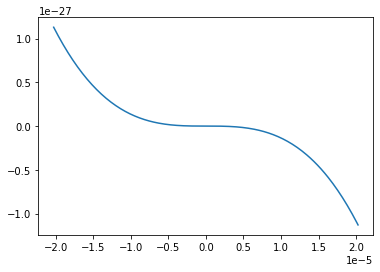

In [17]:
# ポテンシャル1次微分
ax = plt.gca()
plt.plot(grid, infPotDerivFunc(grid))
plt.show()

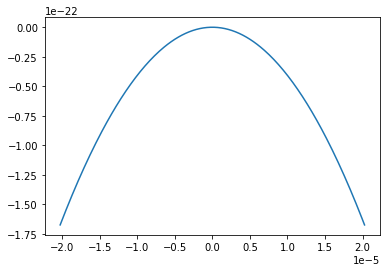

In [18]:
# ポテンシャル2次微分
ax = plt.gca()
plt.plot(grid, infPotDeriv2Func(grid))
plt.show()

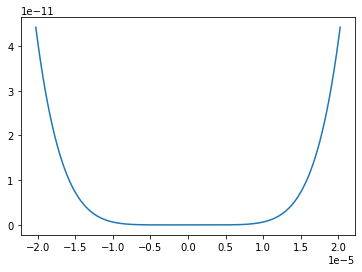

In [19]:
# (v'/v)^2
ax = plt.gca()
plt.plot(grid, (infPotDerivFunc(grid) / infPotFunc(grid)) ** 2)
plt.show()

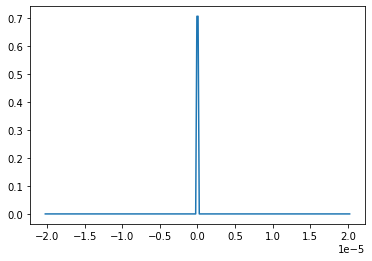

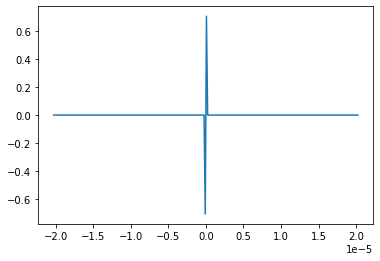

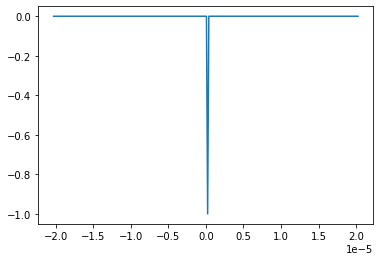

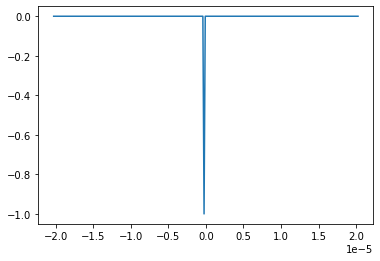

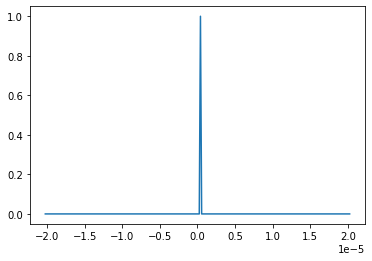

In [20]:
# 固有関数のプロット
ax = plt.gca()

for iEig in range(5):
    plt.plot(grid, eigVecsSort[iEig])
    plt.show()